# ТЗ

The key aspect of ride-hailing is the price. It relies on technology to collect accurate tracking data so that a fair price can be calculated at the end of the trip. Fortunately, our riders are quick to tell us when they overpaid and we can use that feedback to improve our product.

Please analyze the dataset to identify top opportunities for reducing the number of overcharge tickets and present your results. Please provide us with a PDF file/document with the findings. Finally, you shouldn’t spend more than 8 hours on this analysis.

Variables in the file:

order_id_new, order_try_id_new - id of an order

calc_created- time when the order was created

metered_price, distance, duration- actual price, distance and duration of a ride

upfront_price- promised to the rider price, based on predicted duration (predicted_duration) and distance (predicted_distance)

distance - ride distance

duration - ride duration

gps_confidence- indicator for good GPS connection (1 - good one, 0 - bad one)

entered_by- who entered the address

b_state- state of a ride (finished implies that the ride was actually done)

dest_change_number- number of destination changes by a rider

predicted distance - predicted duration of a ride based on the pickup and dropoff points entered by the rider requesting a car

predicted duration - predicted duration of a ride based on the pickup and dropoff points entered by the rider requesting a car

prediction_price_type- internal variable for the type of prediction:

upfront, prediction - prediction happened before the ride

upfront_destination_changed - prediction happened after rider changed destination during the ride

change_reason_pricing - records due to whose action the price changed

ticket_id_new - id for customer support ticket

In [4]:
import pandas as pd

# Загружаем файл по ссылке с гугл диска

In [6]:
file_url = 'https://drive.google.com/uc?export=download&id=1ZNLnbwS3hnhjy3_6CYBcSu_72PCEcnVd'
df = pd.read_csv(file_url)

In [7]:
df

,order_id_new,order_try_id_new,calc_created,metered_price,upfront_price,distance,duration,gps_confidence,entered_by,b_state,...,device_token,rider_app_version,order_state,order_try_state,driver_app_version,driver_device_uid_new,device_name,eu_indicator,overpaid_ride_ticket,fraud_score
0,22,22,2020-02-02 3:37:31,4.04,10.0,2839,700,1,client,finished,...,NaN,CI.4.17,finished,finished,DA.4.37,1596,Xiaomi Redmi 6,1,0,-1383.0
1,618,618,2020-02-08 2:26:19,6.09,3.6,5698,493,1,client,finished,...,NaN,CA.5.43,finished,finished,DA.4.39,1578,Samsung SM-G965F,1,0,NaN
2,657,657,2020-02-08 11:50:35,4.32,3.5,4426,695,1,client,finished,...,NaN,CA.5.43,finished,finished,DA.4.37,951,Samsung SM-A530F,1,0,-166.0
3,313,313,2020-02-05 6:34:54,72871.72,NaN,49748,1400,0,client,finished,...,NaN,CA.5.23,finished,finished,DA.4.37,1587,TECNO-Y6,0,1,NaN
4,1176,1176,2020-02-13 17:31:24,20032.50,19500.0,10273,5067,1,client,finished,...,NaN,CA.5.04,finished,finished,DA.4.37,433,Itel W5504,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4938,3513,3513,2020-03-07 17:42:34,10.89,13.7,15672,1449,1,client,finished,...,NaN,CA.5.45,finished,finished,DA.4.37,1612,HUAWEI LYA-L29,1,0,-286.0
4939,2192,2192,2020-02-22 18:15:45,8789.28,NaN,5712,1173,0,client,finished,...,NaN,CA.5.44,finished,finished,DA.4.37,859,Samsung SM-G928F,0,0,NaN
4940,4051,4051,2020-03-12 23:08:31,7.50,7.4,5303,486,1,client,finished,...,NaN,CA.5.45,finished,finished,DA.4.42,2061,HUAWEI AMN-LX9,1,0,-192.0
4941,3636,3636,2020-03-08 20:15:04,3.06,8.1,3528,338,1,client,finished,...,NaN,CA.5.46,finished,finished,DA.4.39,2101,TP-Link Neffos X1,1,0,-228.0


# Посмотрим на столбцы датасета

In [9]:
df.columns
# здесь таргет это overpaid_ride_ticket

Index(['order_id_new', 'order_try_id_new', 'calc_created', 'metered_price',
       'upfront_price', 'distance', 'duration', 'gps_confidence', 'entered_by',
       'b_state', 'dest_change_number', 'prediction_price_type',
       'predicted_distance', 'predicted_duration', 'change_reason_pricing',
       'ticket_id_new', 'device_token', 'rider_app_version', 'order_state',
       'order_try_state', 'driver_app_version', 'driver_device_uid_new',
       'device_name', 'eu_indicator', 'overpaid_ride_ticket', 'fraud_score'],
      dtype='object')

In [10]:
len(df)

4943

# value_counts()

In [12]:
#Метод value_counts используется для подсчета количества уникальных значений в столбце или строках DataFrame/Series.
df['overpaid_ride_ticket'].value_counts()

overpaid_ride_ticket
0    4606
1     337
Name: count, dtype: int64

# 'calc_created' to_datetime

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id_new           4943 non-null   int64  
 1   order_try_id_new       4943 non-null   int64  
 2   calc_created           4943 non-null   object 
 3   metered_price          4923 non-null   float64
 4   upfront_price          3409 non-null   float64
 5   distance               4943 non-null   int64  
 6   duration               4943 non-null   int64  
 7   gps_confidence         4943 non-null   int64  
 8   entered_by             4943 non-null   object 
 9   b_state                4943 non-null   object 
 10  dest_change_number     4943 non-null   int64  
 11  prediction_price_type  4923 non-null   object 
 12  predicted_distance     4923 non-null   float64
 13  predicted_duration     4923 non-null   float64
 14  change_reason_pricing  298 non-null    object 
 15  tick

 формат 2020-02-02 3:37:31	

In [16]:
df['calc_created'] = pd.to_datetime(df['calc_created'], format='%Y-%m-%d %H:%M:%S')

In [17]:
df['calc_created'].agg(['min', 'max'])

min   2020-02-02 00:01:16
max   2020-03-13 23:52:07
Name: calc_created, dtype: datetime64[ns]

# Смотрим пропуски

In [19]:
df.isna().mean().sort_values(ascending=False)

device_token             1.000000
change_reason_pricing    0.939713
fraud_score              0.558163
upfront_price            0.310338
prediction_price_type    0.004046
predicted_distance       0.004046
predicted_duration       0.004046
metered_price            0.004046
rider_app_version        0.003237
gps_confidence           0.000000
overpaid_ride_ticket     0.000000
eu_indicator             0.000000
device_name              0.000000
driver_device_uid_new    0.000000
driver_app_version       0.000000
order_try_state          0.000000
order_state              0.000000
calc_created             0.000000
entered_by               0.000000
ticket_id_new            0.000000
order_try_id_new         0.000000
distance                 0.000000
duration                 0.000000
dest_change_number       0.000000
b_state                  0.000000
order_id_new             0.000000
dtype: float64

# Делаем Catboost

CatBoost — это библиотека для градиентного бустинга от Yandex, которая особенно эффективно работает с категориальными признаками (номинативными)

In [22]:
!pip install catboost

In [23]:
from catboost import CatBoostClassifier

In [24]:
df = df[(~df['prediction_price_type'].isna()) & (~df['rider_app_version'].isna())].copy()

In [25]:
#model = CatBoostClassifier(verbose = 100)

## Sample для train и test

Метод pandas.DataFrame.sample используется для случайного выбора строк или столбцов из DataFrame. 

In [28]:
df['dt_unix'] = df['calc_created'].astype('int64') / 10**9

In [29]:
train = df.sample(frac=0.7, random_state = 42).copy()

In [30]:
# Метод isin в библиотеке Pandas используется для проверки, содержатся ли элементы DataFrame или Series в заданном наборе значений. 
# Возвращает True или False, в зависимости от того, содержится ли элемент в values.
# проверяет содеражатся ли индексы df в индексах train
~df.index.isin(train.index) # тильда - обратное

array([False, False,  True, ..., False, False, False])

In [31]:
val = df[~df.index.isin(train.index)].copy()

In [32]:
# Проверка
len(df) == len(train) + len(val)

True

In [33]:
df.columns

Index(['order_id_new', 'order_try_id_new', 'calc_created', 'metered_price',
       'upfront_price', 'distance', 'duration', 'gps_confidence', 'entered_by',
       'b_state', 'dest_change_number', 'prediction_price_type',
       'predicted_distance', 'predicted_duration', 'change_reason_pricing',
       'ticket_id_new', 'device_token', 'rider_app_version', 'order_state',
       'order_try_state', 'driver_app_version', 'driver_device_uid_new',
       'device_name', 'eu_indicator', 'overpaid_ride_ticket', 'fraud_score',
       'dt_unix'],
      dtype='object')

## Вычисляем категориальные признаки (object)

In [35]:
#Метод select_dtypes() в библиотеке pandas используется для выбора столбцов из DataFrame на основе их типа данных. 
#Это удобный способ фильтровать столбцы, например, только числовые, строковые или логические.

df.select_dtypes(include='object').isna().mean()
# видим, что в столбцах есть пропуски, надо убирать их

entered_by               0.000000
b_state                  0.000000
prediction_price_type    0.000000
change_reason_pricing    0.939468
rider_app_version        0.000000
order_state              0.000000
order_try_state          0.000000
driver_app_version       0.000000
device_name              0.000000
dtype: float64

In [36]:
df.select_dtypes(include='object').columns

Index(['entered_by', 'b_state', 'prediction_price_type',
       'change_reason_pricing', 'rider_app_version', 'order_state',
       'order_try_state', 'driver_app_version', 'device_name'],
      dtype='object')

In [37]:
#df = df[(~df['prediction_price_type'].isna()) & (~df['rider_app_version'].isna())].copy()

In [38]:
# X_col - это все независимые перерменные, включая непрерывные и категориальные 
X_col = ['order_id_new', 'order_try_id_new', 'metered_price',
       'upfront_price', 'distance', 'duration', 'gps_confidence', 'entered_by',
       'b_state', 'dest_change_number', 'prediction_price_type',
       'predicted_distance', 'predicted_duration',
       'ticket_id_new', 'device_token', 'rider_app_version', 'order_state',
       'order_try_state', 'driver_app_version', 'driver_device_uid_new',
       'device_name', 'eu_indicator', 'fraud_score',
       'dt_unix']
# y_col - зависимая переменная
y_col = ['overpaid_ride_ticket']
# Отдельно указываем категориальные переменные
cat_features = ['entered_by', 'b_state', 'prediction_price_type',
       'rider_app_version', 'order_state',
       'order_try_state', 'driver_app_version', 'device_name']

## Строим модель Catboost

In [40]:
model = CatBoostClassifier(learning_rate=0.005, eval_metric='AUC', cat_features=cat_features, verbose = 100)

In [41]:
model.fit(train[X_col], train[y_col], 
          eval_set=(val[X_col], val[y_col]))

0:	test: 0.8134606	best: 0.8134606 (0)	total: 189ms	remaining: 3m 9s
100:	test: 0.8488624	best: 0.8488912 (93)	total: 4.5s	remaining: 40s
200:	test: 0.8575905	best: 0.8575905 (200)	total: 9.66s	remaining: 38.4s
300:	test: 0.8634117	best: 0.8634261 (298)	total: 15.6s	remaining: 36.3s
400:	test: 0.8649407	best: 0.8654732 (378)	total: 21.5s	remaining: 32.2s
500:	test: 0.8648040	best: 0.8655811 (458)	total: 28.2s	remaining: 28.1s
600:	test: 0.8648616	best: 0.8655811 (458)	total: 34.8s	remaining: 23.1s
700:	test: 0.8644010	best: 0.8655811 (458)	total: 41.4s	remaining: 17.6s
800:	test: 0.8645593	best: 0.8655811 (458)	total: 48.1s	remaining: 12s
900:	test: 0.8644694	best: 0.8655811 (458)	total: 54.5s	remaining: 5.99s
999:	test: 0.8648220	best: 0.8655811 (458)	total: 1m 1s	remaining: 0us

bestTest = 0.8655811075
bestIteration = 458

Shrink model to first 459 iterations.


## Смотрим на важные признаки 

Feature Importance: встроенные методы для оценки важности признаков позволяют понять, какие из них наиболее влиятельны:

In [44]:
fi = pd.DataFrame({'feature':X_col,
    'fi':model.feature_importances_})
fi.sort_values('fi', ascending=False)

,feature,fi
2,metered_price,13.985340
10,prediction_price_type,12.379858
21,eu_indicator,12.107867
22,fraud_score,8.901335
6,gps_confidence,7.448661
20,device_name,6.554602
5,duration,5.469510
3,upfront_price,5.262882
18,driver_app_version,4.596941
4,distance,4.086869


<Axes: xlabel='feature'>

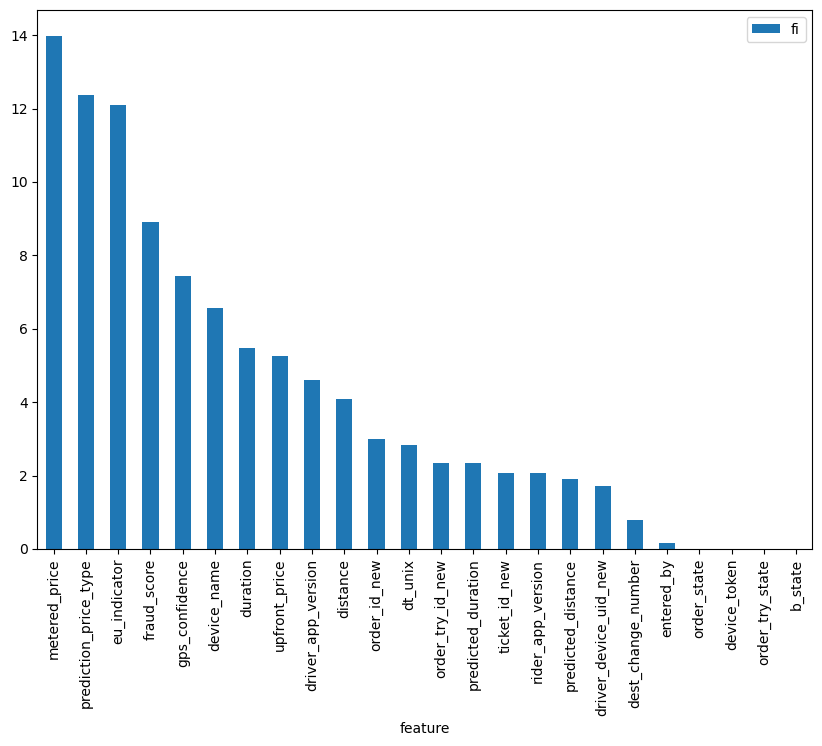

In [45]:
fi.sort_values('fi', ascending=False).set_index('feature').plot(kind = 'bar',figsize = (10, 7))

<Axes: ylabel='Frequency'>

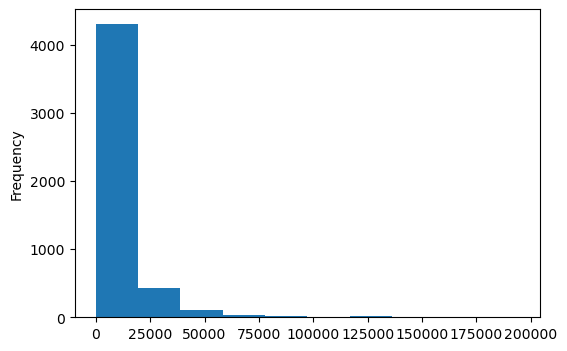

In [46]:
df['metered_price'].plot(kind = 'hist', figsize = (6, 4))

In [47]:
df['metered_price']

0           4.04
1           6.09
2           4.32
3       72871.72
4       20032.50
          ...   
4938       10.89
4939     8789.28
4940        7.50
4941        3.06
4942    29244.10
Name: metered_price, Length: 4923, dtype: float64

### Сводная по metered_price

In [49]:
df['metered_price_bin'] = pd.qcut(df['metered_price'], 5)

In [50]:
df.groupby('metered_price_bin')['overpaid_ride_ticket'].agg(['count', 'mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_17036\646201450.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('metered_price_bin')['overpaid_ride_ticket'].agg(['count', 'mean'])


,count,mean
metered_price_bin,,
"(1.999, 4.72]",992,0.000000
"(4.72, 8.25]",978,0.005112
"(8.25, 6000.0]",1291,0.040279
"(6000.0, 13835.1]",677,0.138848
"(13835.1, 194483.52]",985,0.188832


т.е. из 985 дорогих поездок 20% оверпэид

### Сводная по prediction_price_type

In [53]:
df.groupby(df['prediction_price_type'])['overpaid_ride_ticket'].agg(['count', 'mean'])

,count,mean
prediction_price_type,,
prediction,1279,0.173573
upfront,3432,0.032634
upfront_destination_changed,208,0.014423
upfront_waypoint_changed,4,0.000000


### Сводная по eu_indicator

In [55]:
df.groupby('eu_indicator')['overpaid_ride_ticket'].agg(['count', 'mean'])

,count,mean
eu_indicator,,
0,2173,0.149103
1,2750,0.004727


т.е. когда eu_indicator = 1, то оверпэидных поездок 0%, а когда 0 - то 15%

### Сводная по fraud_score

In [58]:
df['fraud_score_bin'] = pd.qcut(df['fraud_score'], 5, duplicates = 'drop')

In [101]:
df.groupby('fraud_score_bin', dropna = False)['overpaid_ride_ticket'].agg(['count', 'mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_17036\2115019181.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('fraud_score_bin', dropna = False)['overpaid_ride_ticket'].agg(['count', 'mean'])


,count,mean
fraud_score_bin,,
"(-14225.001, -1025.6]",437,0.013730
"(-1025.6, -426.0]",439,0.004556
"(-426.0, -184.0]",435,0.006897
"(-184.0, -36.0]",437,0.009153
"(-36.0, 49.0]",434,0.004608
NaN,2741,0.116746


`т.е. здесь если fraud_score не заполнен, то поездка в 11% оверпрайс.Т.е. возможно не указанный fraud_score сильно оверпрайсит поездку`

### Сводная по gps_confidence

In [107]:
df.groupby('gps_confidence')['overpaid_ride_ticket'].agg(['count', 'mean'])

,count,mean
gps_confidence,,
0,983,0.204476
1,3940,0.034518


т.е. когда плохое gps-соединение (0), то оверпрайс - 20% 

### Сводная по device_name

In [122]:
t = df.groupby('device_name')['overpaid_ride_ticket'].agg(['count', 'mean'])
t.sort_values('count', ascending=False)

,count,mean
device_name,,
TECNO MOBILE LIMITED TECNO B1p,108,0.259259
HMD Global Nokia 2.2,98,0.040816
"iPhone8,1",89,0.011236
TECNO F3,86,0.151163
HUAWEI MAR-LX1A,72,0.000000
...,...,...
Itel it1407,1,0.000000
Samsung SM-N920V,1,0.000000
HTC U Ultra,1,1.000000


#### Функция для каждой строки столбца

In [159]:
def device_cat(device_name):
    if 'tecno' in device_name.lower():
        return 'tecno'
    if 'iphone' in device_name.lower():
        return 'iphone'
    if 'samsung' in device_name.lower():
        return 'samsung'
    if 'lge' in device_name.lower():
        return 'lge'
    if 'huawei' in device_name.lower():
        return 'huawei'
    if 'nokia' in device_name.lower():
        return 'nokia'
    if 'htc' in device_name.lower():
        return 'htc'
    if 'xiaomi' in device_name.lower():
        return 'xiaomi'
    else:
        return 'misc'

In [161]:
df['device_group'] = df['device_name'].apply(device_cat)

In [165]:
df.groupby('device_group')['overpaid_ride_ticket'].agg(['count', 'mean']).sort_values('mean', ascending = False)

,count,mean
device_group,,
htc,16,0.312500
tecno,933,0.167203
nokia,158,0.113924
misc,700,0.095714
samsung,1675,0.038806
iphone,424,0.021226
huawei,720,0.019444
xiaomi,258,0.011628
lge,39,0.000000


получается, что у девайсов tecno 16% оверпрайс поездки

### Сводная по duration

# Shap

In [170]:
!pip install shap


   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/548.0 kB ? eta -:--:--
   -------------------------------------- 548.0/548.0 kB 965.9 kB/s eta 0:00:00


In [176]:
import shap
#load JS visualization code to notebook
shap.initjs()

# train an XGBoost model
# done catboost 

# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.Explainer(model)
shap_values = explainer(train[X_col])

# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[0])

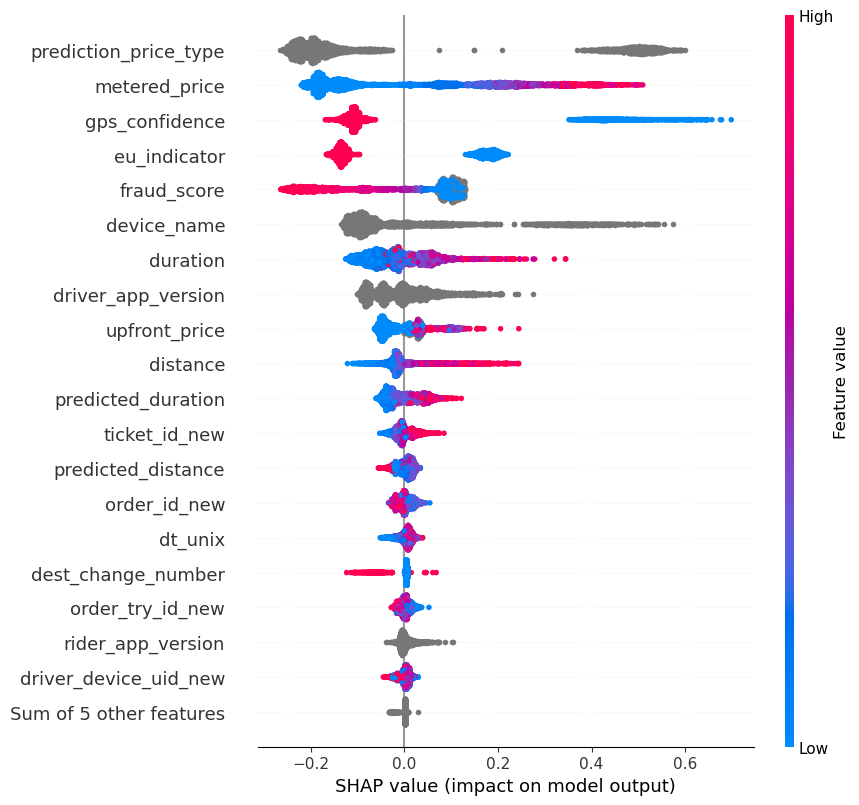

In [187]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values, max_display = 20)
# серым отмечены категориальные фичи

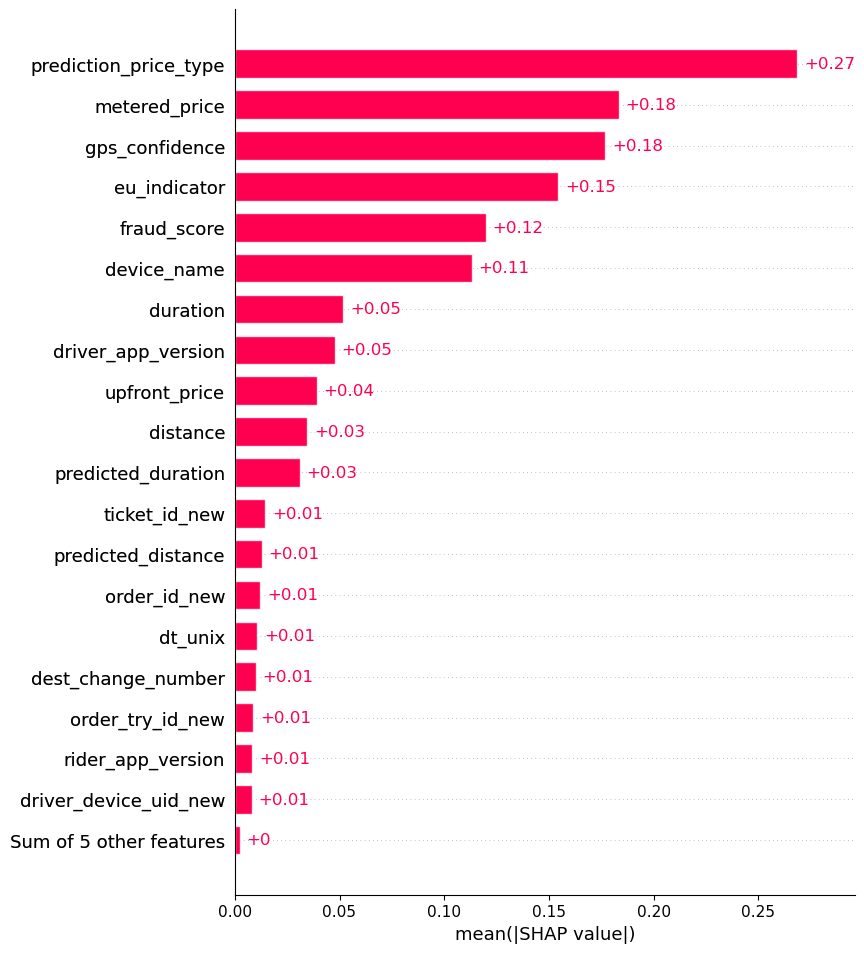

In [191]:
shap.plots.bar(shap_values, max_display = 20)

# Смотрим на предикты

In [194]:
df.columns

Index(['order_id_new', 'order_try_id_new', 'calc_created', 'metered_price',
       'upfront_price', 'distance', 'duration', 'gps_confidence', 'entered_by',
       'b_state', 'dest_change_number', 'prediction_price_type',
       'predicted_distance', 'predicted_duration', 'change_reason_pricing',
       'ticket_id_new', 'device_token', 'rider_app_version', 'order_state',
       'order_try_state', 'driver_app_version', 'driver_device_uid_new',
       'device_name', 'eu_indicator', 'overpaid_ride_ticket', 'fraud_score',
       'dt_unix', 'metered_price_bin', 'fraud_score_bin', 'device_group'],
      dtype='object')

`У нас есть 'distance', 'duration' и 'predicted_distance', 'predicted_duration'. Сейчас нам нужно понять где больше всего алгоритм предсказания ошибается`

In [201]:
df['distance_error'] = df['distance'] - df['predicted_distance']
df['duration_error'] = df['duration'] - df['predicted_duration']

In [203]:
import numpy as np

In [239]:
# посчитаем ошибку
df['distance_error_percent'] = np.abs(df['distance_error']/df['distance'])
df['duration_error_percent'] = np.abs(df['duration_error']/df['duration'])

In [235]:
df.replace([np.inf, -np.inf], np.nan)['distance_error_percent'].agg(['mean', 'median'])

mean      3743.429549
median      16.302593
Name: distance_error_percent, dtype: float64

In [237]:
df.replace([np.inf, -np.inf], np.nan)['duration_error_percent'].agg(['mean', 'median'])

mean      319.550608
median     27.910448
Name: duration_error_percent, dtype: float64

In [219]:
df[df['distance_error_percent'] == np.inf]
# нужно избавиться от inf, получаемых при делении на ноль

,order_id_new,order_try_id_new,calc_created,metered_price,upfront_price,distance,duration,gps_confidence,entered_by,b_state,...,overpaid_ride_ticket,fraud_score,dt_unix,metered_price_bin,fraud_score_bin,device_group,distance_error,duration_error,distance_error_percent,duration_error_percent
44,3696,3696,2020-03-09 13:46:46,6000.0,NaN,0,5,1,client,finished,...,0,NaN,1.583762e+09,"(8.25, 6000.0]",NaN,misc,-5535.0,-956.0,inf,191.200000
88,980,980,2020-02-11 15:09:39,6000.0,26500.0,0,0,0,client,finished,...,0,NaN,1.581434e+09,"(8.25, 6000.0]",NaN,tecno,-18253.0,-2852.0,inf,inf
96,2463,2463,2020-02-25 12:48:24,6000.0,NaN,0,2,1,client,finished,...,0,NaN,1.582635e+09,"(8.25, 6000.0]",NaN,misc,-5834.0,-1182.0,inf,591.000000
221,1235,1235,2020-02-14 09:36:53,6000.0,16000.0,0,0,0,client,finished,...,0,NaN,1.581673e+09,"(8.25, 6000.0]",NaN,samsung,-12391.0,-1750.0,inf,inf
304,492,492,2020-02-07 05:50:32,6000.0,28500.0,0,119,1,client,finished,...,0,NaN,1.581055e+09,"(8.25, 6000.0]",NaN,tecno,-21603.0,-1509.0,inf,12.680672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4633,293,293,2020-02-04 19:26:47,6000.0,6000.0,0,7,1,client,finished,...,0,NaN,1.580844e+09,"(8.25, 6000.0]",NaN,huawei,-2340.0,-422.0,inf,60.285714
4689,3605,3605,2020-03-08 12:42:49,6000.0,NaN,0,60,1,client,finished,...,0,NaN,1.583671e+09,"(8.25, 6000.0]",NaN,misc,-2906.0,-345.0,inf,5.750000
4724,621,621,2020-02-08 02:38:23,4.0,10.7,0,190,1,client,finished,...,0,-82.0,1.581130e+09,"(1.999, 4.72]","(-184.0, -36.0]",huawei,-8131.0,-846.0,inf,4.452632
4787,4049,4049,2020-03-12 23:04:25,6000.0,NaN,0,32,1,client,finished,...,0,NaN,1.584054e+09,"(8.25, 6000.0]",NaN,tecno,-8442.0,-1171.0,inf,36.593750


<Axes: >

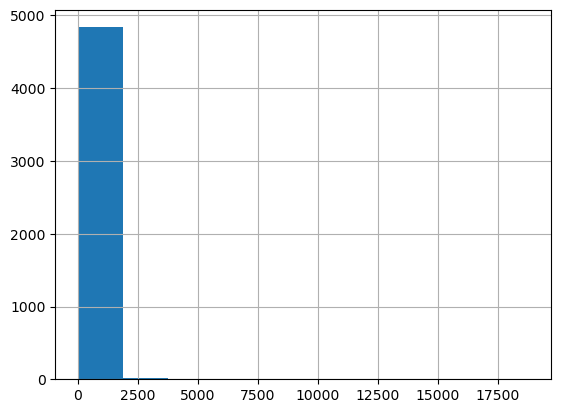

In [225]:
df.replace([np.inf, -np.inf], np.nan)['distance_error_percent'].hist()

<Axes: >

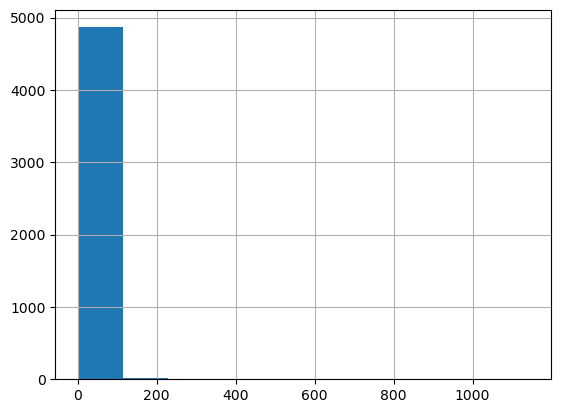

In [227]:
df.replace([np.inf, -np.inf], np.nan)['duration_error_percent'].hist()

<Axes: >

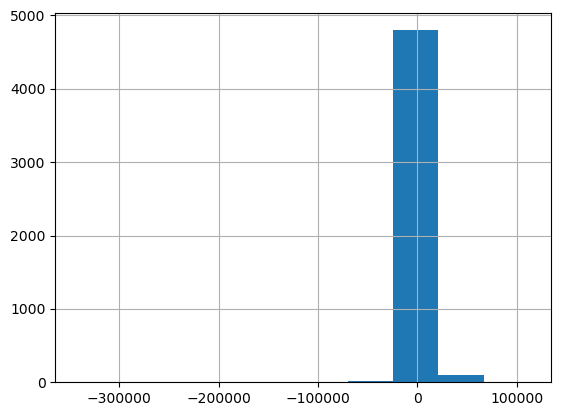

In [229]:
df.replace([np.inf, -np.inf], np.nan)['distance_error'].hist()

<Axes: >

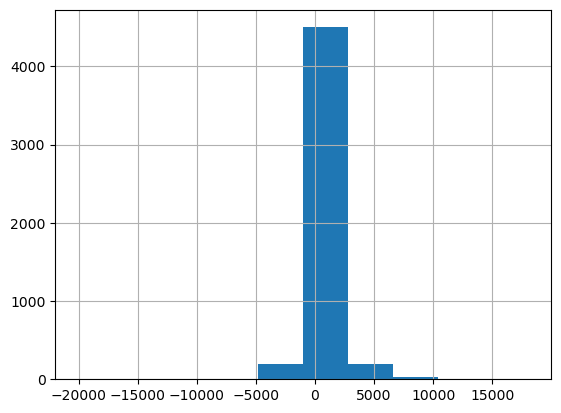

In [231]:
df.replace([np.inf, -np.inf], np.nan)['duration_error'].hist()

## Сводная по distance_error

In [243]:
df['distance_error_bin'] = pd.qcut(df['distance_error'], 5)

In [251]:
df.groupby('distance_error_bin')[['overpaid_ride_ticket', 'upfront_price', 'metered_price']].agg(['count', 'mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_17036\3882032052.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('distance_error_bin')[['overpaid_ride_ticket', 'upfront_price', 'metered_price']].agg(['count', 'mean'])


overpaid_ride_ticket           upfront_price  \
                                     count      mean         count   
distance_error_bin                                                   
(-341860.001, -754.8]                  985  0.072081           622   
(-754.8, 0.0]                         1007  0.065541           693   
(0.0, 581.4]                           962  0.028067           784   
(581.4, 2466.0]                        984  0.033537           743   
(2466.0, 112012.0]                     985  0.142132           567   

                                   metered_price                
                              mean         count          mean  
distance_error_bin                                              
(-341860.001, -754.8]  9338.362058           985   6481.735442  
(-754.8, 0.0]          2072.340693          1007   5745.271192  
(0.0, 581.4]           1255.807270           962   3210.857422  
(581.4, 2466.0]        2696.943607           984   5552.151494  
(2466.0, 112012.0]     6964.358201           985  18938.390640

`Получается что оверпарйс при положительной distance_error, т.е. когда predicted_distance < distance. Т.е. прогнозируемая цена меньше реальной. По итогу получается переплата. Предикт цена маленькая, а по факту в 3 раза больше`

## Сводная по duration_error

In [257]:
df['duration_error_bin'] = pd.qcut(df['duration_error'], 5)

In [259]:
df.groupby('duration_error_bin')[['overpaid_ride_ticket', 'upfront_price', 'metered_price']].agg(['count', 'mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_17036\1791900311.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('duration_error_bin')[['overpaid_ride_ticket', 'upfront_price', 'metered_price']].agg(['count', 'mean'])


overpaid_ride_ticket           upfront_price  \
                                    count      mean         count   
duration_error_bin                                                  
(-20081.001, -122.0]                  986  0.070994           729   
(-122.0, 34.0]                        988  0.033401           880   
(34.0, 257.0]                         982  0.027495           787   
(257.0, 845.0]                        983  0.090539           624   
(845.0, 18086.0]                      984  0.119919           389   

                                   metered_price                
                              mean         count          mean  
duration_error_bin                                              
(-20081.001, -122.0]   7674.807545           986   6989.042434  
(-122.0, 34.0]          780.946477           988   1707.660152  
(34.0, 257.0]          1541.834180           982   3134.069287  
(257.0, 845.0]         3527.216026           983   8091.943194  
(845.0, 18086.0]      11530.057841           984  20087.473496